In [1]:
import control_dde.models
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from control_dde.models import base_trainer

In [45]:
path_data_folder: str = (
    "/home/hosseinkhan/Documents/work/phd"
    "/git_repositories/control_dde/data/examples"
    "/python_scripts/generating_trajectory_data"
    "/pendulum_num_traj-10_num_steps-100_seed-93/"
    "trajectory_data"
)
path_data_array3d_x: str = f"{path_data_folder}/observations.npy"
path_data_array3d_control: str = f"{path_data_folder}/controls.npy"

array3d_x: npt.NDArray
array3d_control: npt.NDArray

In [46]:
name_model: str = "linear_regression_ols"
dict_model_params: dict = {}
path_model: str = (
    "/home/hosseinkhan/Documents/work/phd"
    "/git_repositories/control_dde/data"
    "/mlruns/3/9d91514f51cc4dc2975d4b55b0d9c41d"
    "/generated_data/trainer_data/model.pkl"
)

# Get the model from the string
model = control_dde.models.model_from_string(
    name_model=name_model, dict_model_params=dict_model_params
)

# Get the trainer from the string
trainer: base_trainer.BaseTrainer = control_dde.models.trainer_from_string(
    name_trainer=name_model,
    model=model,
    saving_path="",  # Saving path is not necessary as we are not training here yet
)

# Load the model
trainer.load_model(path_model=path_model)

Loading model from /home/hosseinkhan/Documents/work/phd/git_repositories/control_dde/data/mlruns/3/9d91514f51cc4dc2975d4b55b0d9c41d/generated_data/trainer_data/model.pkl, this overwrites the current modelin self.model attribute.


In [47]:
# Plot observations against predictions
array3d_x = np.load(path_data_array3d_x)
array3d_control = np.load(path_data_array3d_control)

# def callable_dynamics(
#         self,
#         t: float,
#         array_x: npt.NDArray[np.floating],
#         list_array_obs_history: list[npt.NDArray[np.floating]],
#         array_control: npt.NDArray[np.floating],
# ) -> npt.NDArray[np.floating]:

In [48]:
matrix_x = array3d_x[:, :-1, :].reshape(-1, array3d_x.shape[-1])
matrix_y = array3d_x[:, 1:, :].reshape(-1, array3d_x.shape[-1])
matrix_u = array3d_control[:, :, :].reshape(-1, array3d_control.shape[-1])
matrix_x_u = np.concatenate((matrix_x, matrix_u), axis=1)

In [49]:
# Plot informations regarding the model
print(trainer.model)
# Plot R^2 score
print(f"R^2 score: {trainer.model.score(matrix_x_u, matrix_y)}")
# Plot coefficients
print(f"Coefficients: {trainer.model.coef_}")
# Plot intercept
print(f"Intercept: {trainer.model.intercept_}")
# Plot residuals

LinearRegression()
R^2 score: 0.9839214493485843
Coefficients: [[ 9.79630589e-01 -2.36045810e-02  3.18695398e-04 -5.64715923e-03]
 [ 2.76144481e-02  9.72715355e-01 -2.24058403e-02 -1.25054638e-03]
 [ 2.49921029e-04  7.47905431e-01  9.98651935e-01  1.47660030e-01]]
Intercept: [-0.0047004   0.0109577   0.00065635]


In [50]:
matrix_y_pred = trainer.model.predict(matrix_x_u)

In [51]:
matrix_y.shape

(1000, 3)

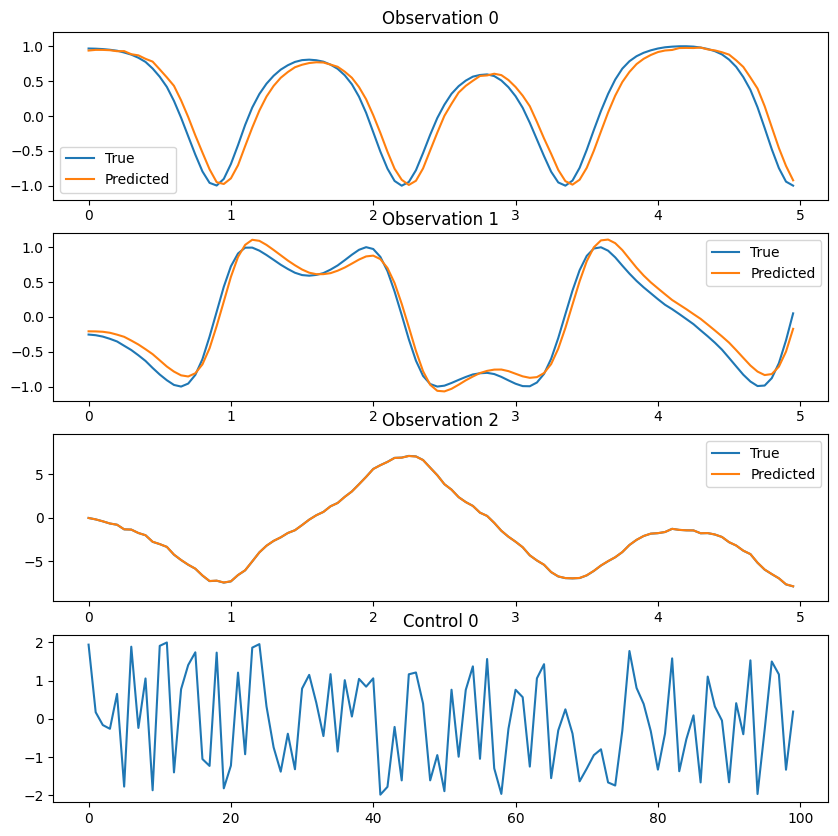

Next Trajectory


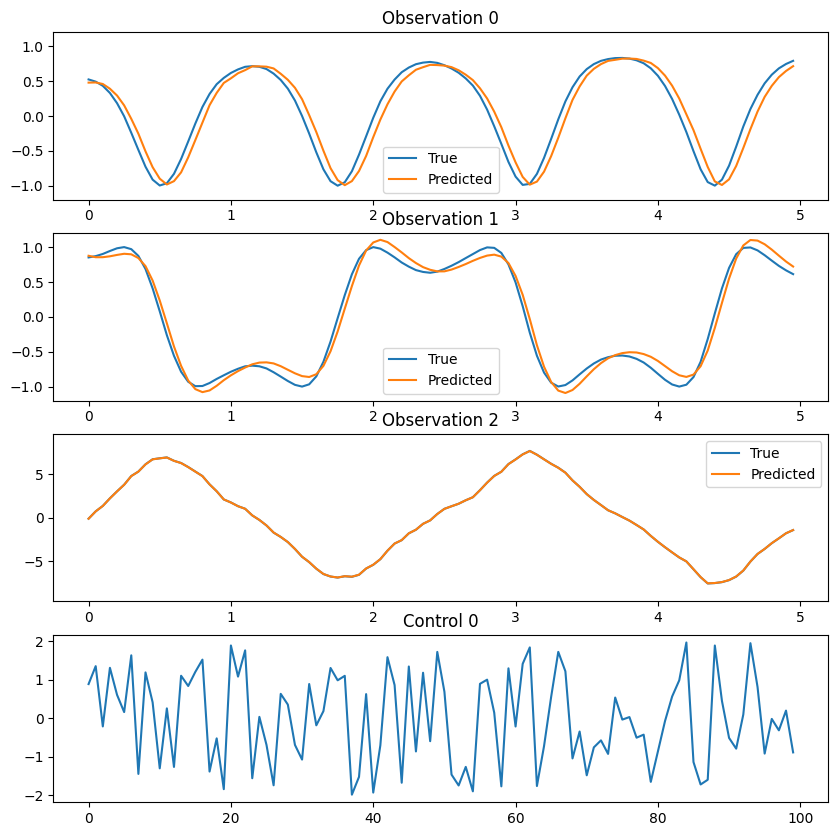

Next Trajectory


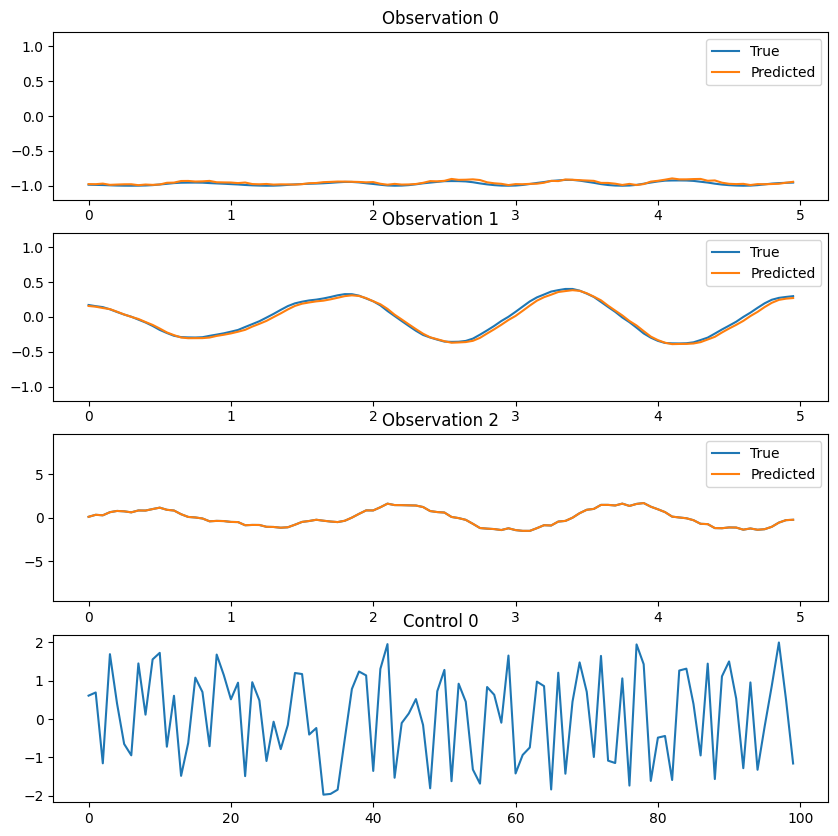

Next Trajectory


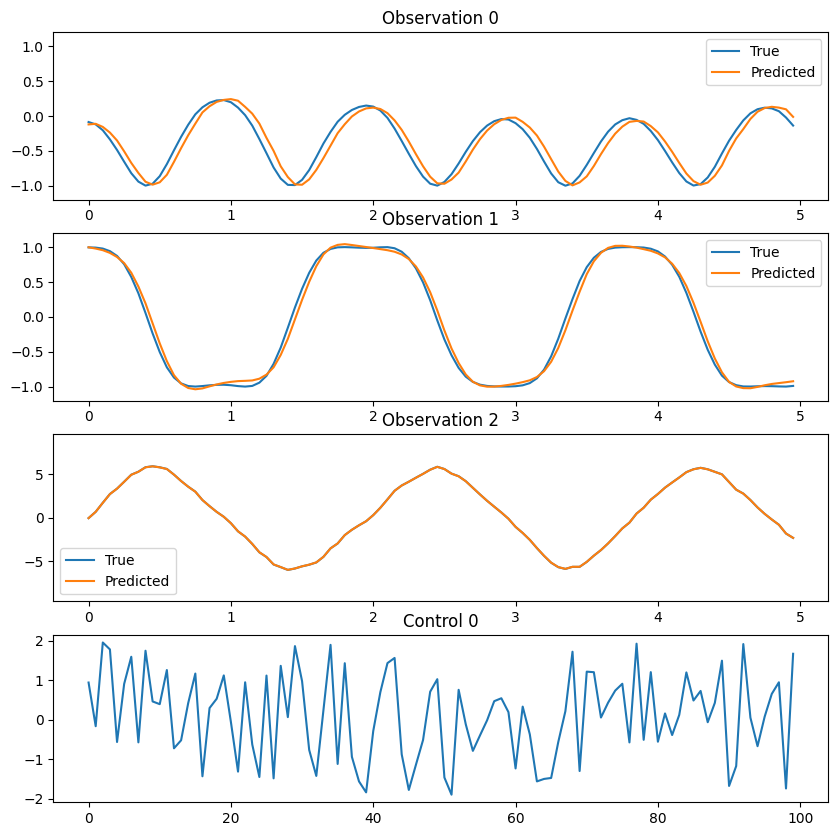

Next Trajectory


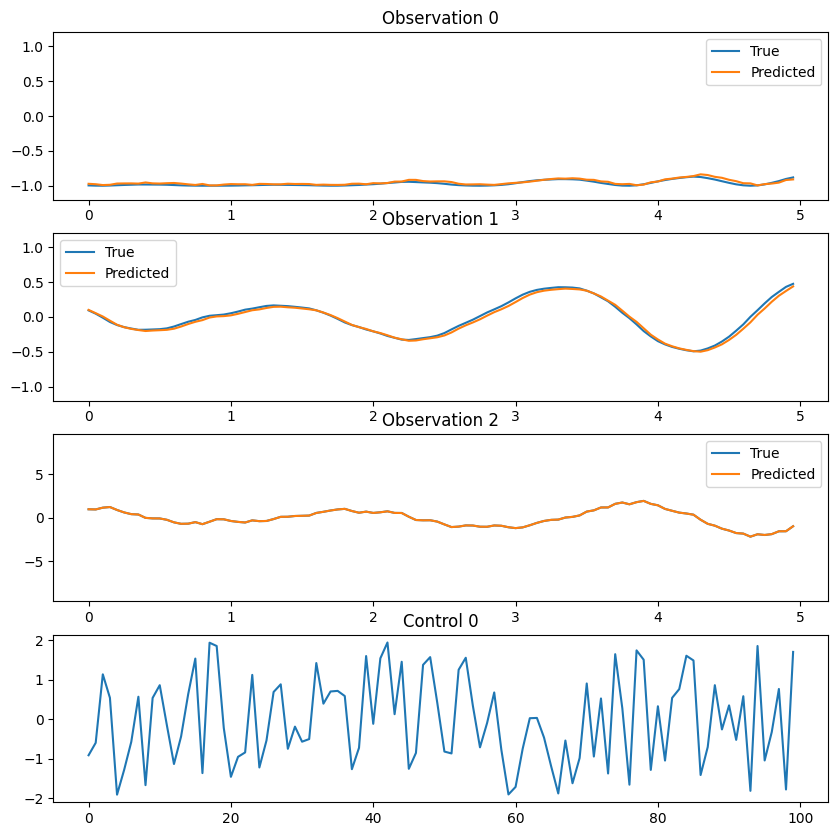

Next Trajectory


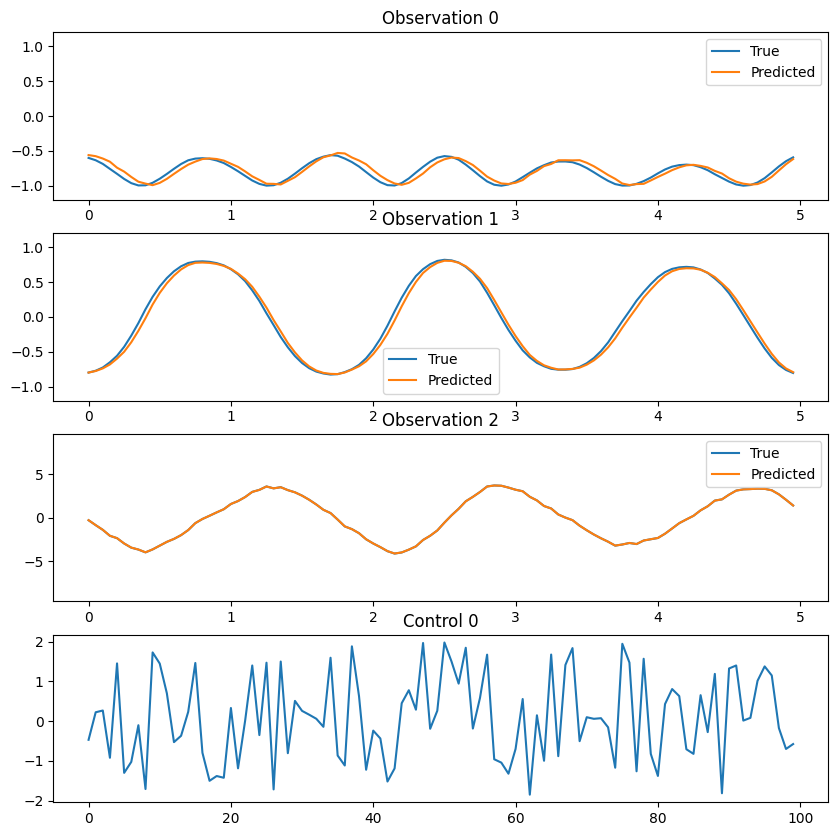

Next Trajectory


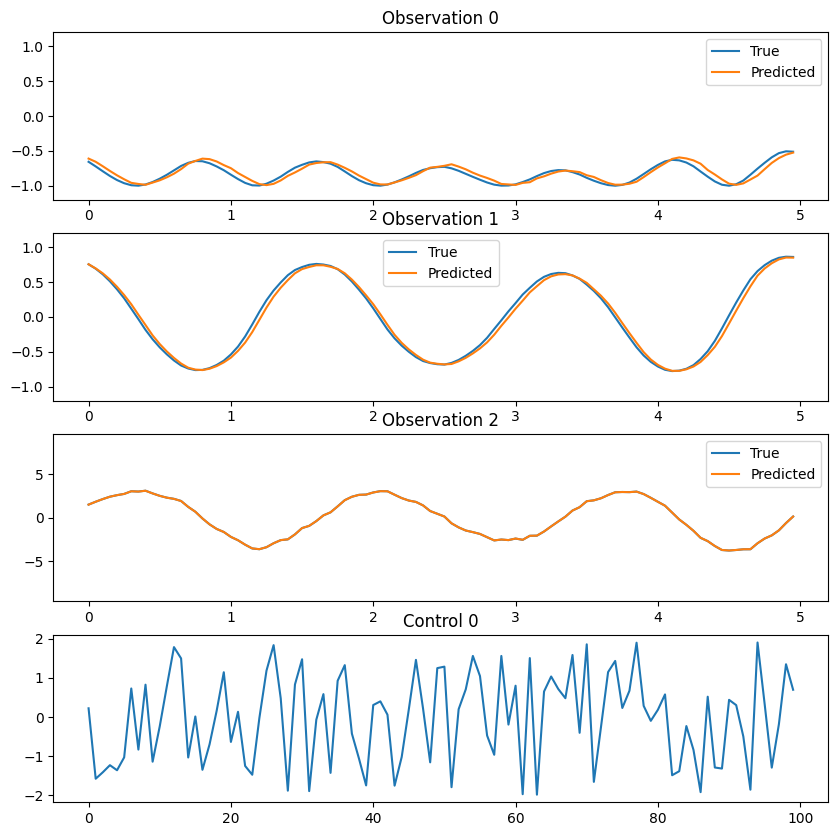

Next Trajectory


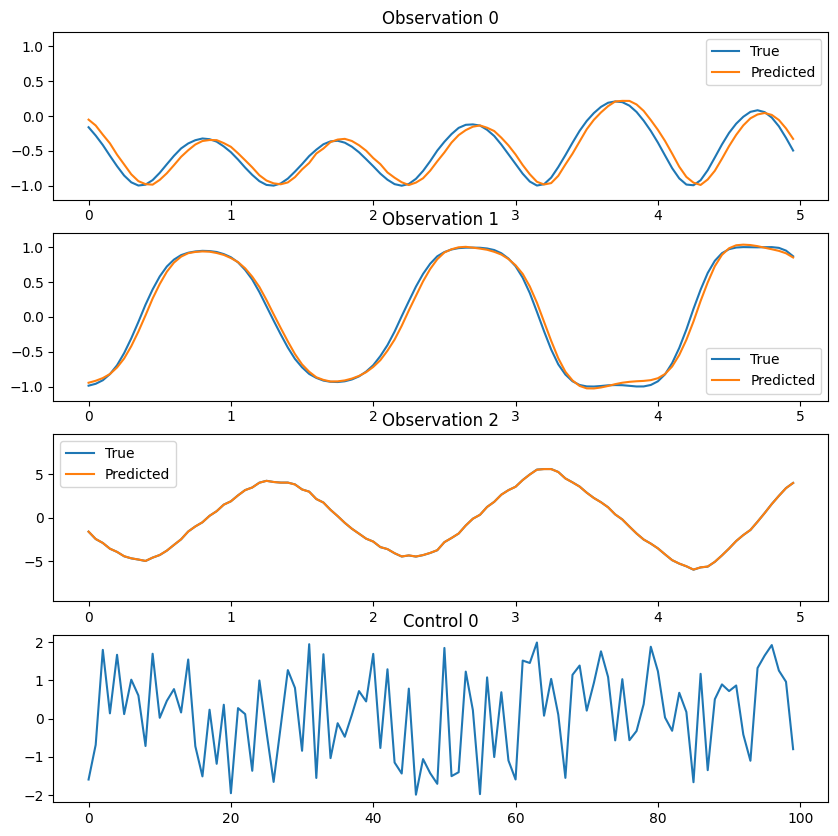

Next Trajectory


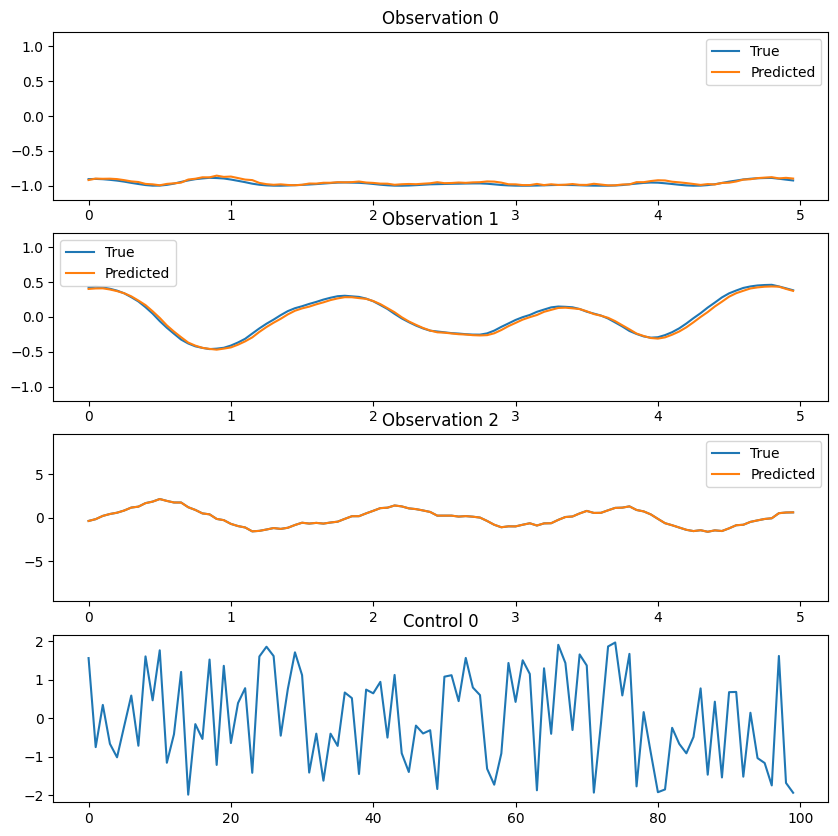

Next Trajectory


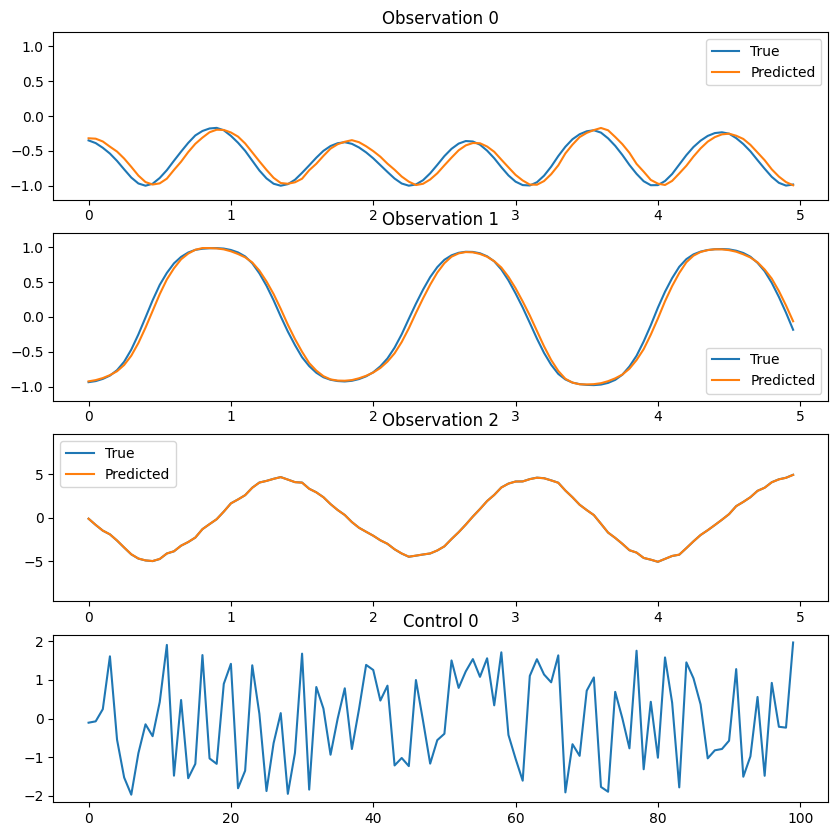

Next Trajectory


In [52]:
# Plot the first trajectory
num_trajectories = array3d_x.shape[0]
num_steps = array3d_control.shape[1]
dim_obs = array3d_x.shape[2]
dim_control = array3d_control.shape[2]
dt = 0.05

for index_traj in range(num_trajectories):
    fig, axs = plt.subplots(dim_obs + dim_control, 1, figsize=(10, 10))
    # Set a symmetric y-axis
    margin = 1.20
    axs[0].set_ylim([-1 * margin, 1 * margin])
    axs[1].set_ylim([-1 * margin, 1 * margin])
    axs[2].set_ylim([-8 * margin, 8 * margin])

    for i in range(dim_obs):
        # Plot obs trajectory and control
        axs[i].plot(
            np.arange(num_steps) * dt,
            matrix_y[index_traj * num_steps : (index_traj + 1) * num_steps, i],
            label="True",
        )
        axs[i].plot(
            np.arange(num_steps) * dt,
            matrix_y_pred[index_traj * num_steps : (index_traj + 1) * num_steps, i],
            label="Predicted",
        )
        axs[i].legend()
        axs[i].title.set_text(f"Observation {i}")

    for i in range(dim_control):
        axs[dim_obs + i].plot(
            np.arange(num_steps),
            matrix_u[index_traj * num_steps : (index_traj + 1) * num_steps, i],
        )
        axs[dim_obs + i].title.set_text(f"Control {i}")

    plt.show()
    print("Next Trajectory")